In [1]:
import os
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

/Users/mironshoh/Documents/dl/dl/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)

Device: mps


In [5]:
MODEL_NAME = "bert-base-uncased"   # 12 layers, 768 hidden size, 110M parameters

MAX_LEN = 256          # tokens per review; anything longer is truncated
TRAIN_SIZE = 5000      # subset of the 25k training reviews
VAL_SIZE = 2000        # subset of the 25k test reviews

BATCH_SIZE = 16
EPOCHS = 2
LEARNING_RATE = 2e-5   # fine-tuning needs a far smaller lr than training from scratch
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1     # share of steps spent warming the lr up from 0
MAX_GRAD_NORM = 1.0
LOG_EVERY = 50         # steps between progress prints

LABELS = ["salbiy", "ijobiy"]

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
raw = load_dataset("imdb")
print(raw)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [6]:
example = raw["train"][0]

print("Label:", example["label"], "->", LABELS[example["label"]])
print("Characters:", len(example["text"]))
print()
print(example["text"][:700], "...")

Label: 0 -> salbiy
Characters: 1640

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ...


In [7]:
train_raw = raw["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
val_raw = raw["test"].shuffle(seed=SEED).select(range(VAL_SIZE))

print("Train:", len(train_raw), "| label counts:", np.bincount(train_raw["label"]))
print("Val  :", len(val_raw), "| label counts:", np.bincount(val_raw["label"]))


Train: 5000 | label counts: [2494 2506]
Val  : 2000 | label counts: [1000 1000]


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample = "This movie was absolutely unwatchable"
encoded = tokenizer(sample)

print("Tokens :", tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("Ids    :", encoded["input_ids"])
print("Keys   :", list(encoded.keys()))
print("Mask   :", encoded["attention_mask"])
print("Vocab size:", tokenizer.vocab_size)

Tokens : ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'un', '##watch', '##able', '[SEP]']
Ids    : [101, 2023, 3185, 2001, 7078, 4895, 18866, 3085, 102]
Keys   : ['input_ids', 'token_type_ids', 'attention_mask']
Mask   : [1, 1, 1, 1, 1, 1, 1, 1, 1]
Vocab size: 30522


Median: 231 | 90%: 624 | 95%: 869 | max: 1416
Truncated at MAX_LEN=256: 43.6% of reviews


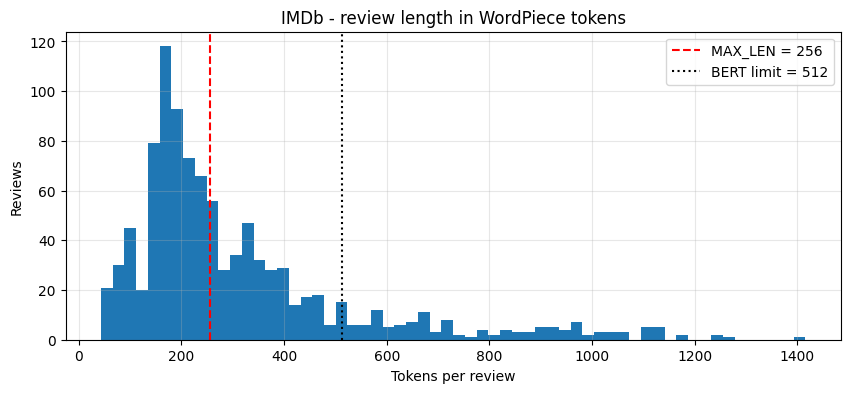

In [9]:
lengths = [
    len(tokenizer(text, truncation=False, verbose=False)["input_ids"])
    for text in train_raw["text"][:1000]
]

print(f"Median: {np.median(lengths):.0f} | 90%: {np.percentile(lengths, 90):.0f} "
      f"| 95%: {np.percentile(lengths, 95):.0f} | max: {max(lengths)}")
print(f"Truncated at MAX_LEN={MAX_LEN}: {np.mean(np.array(lengths) > MAX_LEN):.1%} of reviews")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=60)
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.axvline(512, color="black", linestyle=":", label="BERT limit = 512")
plt.xlabel("Tokens per review")
plt.ylabel("Reviews")
plt.title("IMDb - review length in WordPiece tokens")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
def tokenize(batch):
    return tokenizer(batch['text'], truncation = True, max_length = MAX_LEN)

train_ds = train_raw.map(tokenize, batched=True, remove_columns=["text"])
val_ds = val_raw.map(tokenize, batched=True, remove_columns=["text"])

train_ds = train_ds.rename_column("label", "labels")
val_ds = val_ds.rename_column("label", "labels")

train_ds.set_format("torch")
val_ds.set_format("torch")

print(train_ds)
print("\nFirst example ids:", train_ds[0]["input_ids"][:12].tolist())
print("First example label:", train_ds[0]["labels"].item())

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})

First example ids: [101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337]
First example label: 1


In [11]:
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

batch = next(iter(train_loader))
for key, value in batch.items():
    print(f"{key:16s} {tuple(value.shape)}")

print("\nBatches per epoch:", len(train_loader))


labels           (16,)
input_ids        (16, 256)
token_type_ids   (16, 256)
attention_mask   (16, 256)

Batches per epoch: 313


In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "salbiy", 1: "ijobiy"},
    label2id={"salbiy": 0, "ijobiy": 1},
).to(DEVICE)

encoder_params = sum(p.numel() for p in model.base_model.parameters())
head_params = sum(p.numel() for p in model.classifier.parameters())

print(f"Pretrained encoder : {encoder_params:,} parameters")
print(f"New classifier head: {head_params:,} parameters")
print()
print(model.classifier)

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print("Total steps:", total_steps, "| warmup steps:", warmup_steps)


In [ ]:
@torch.no_grad()
def evaluate(loader):
    model.eval()

    total_loss = 0.0
    preds, gold, probs = [], [], []

    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)

        total_loss += outputs.loss.item() * len(batch["labels"])
        probs.append(torch.softmax(outputs.logits, dim=-1).cpu())
        preds += outputs.logits.argmax(dim=-1).cpu().tolist()
        gold += batch["labels"].cpu().tolist()

    return {
        "loss": total_loss / len(gold),
        "accuracy": accuracy_score(gold, preds),
        "f1": f1_score(gold, preds),
        "preds": np.array(preds),
        "gold": np.array(gold),
        "probs": torch.cat(probs).numpy(),
    }

In [ ]:
baseline = evaluate(val_loader)

print(f"Before fine-tuning | loss: {baseline['loss']:.4f} "
      f"| accuracy: {baseline['accuracy']:.4f} | f1: {baseline['f1']:.4f}")

In [ ]:
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    step_losses = []

    for step, batch in enumerate(train_loader, start = 1):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss()
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        step_losses.append(loss.item())

        if step % LOG_EVERY == 0:
            print(f"  epoch {epoch} | step {step:4d}/{len(train_loader)} "
                  f"| loss {running_loss / step:.4f} "
                  f"| lr {scheduler.get_last_lr()[0]:.2e}")

    return running_loss / len(train_loader), step_losses

In [ ]:
history = {
    "val_loss": [baseline["loss"]],
    "val_acc": [baseline["accuracy"]],
    "val_f1": [baseline["f1"]],
    "train_loss": [],
}
all_step_losses = []

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, step_losses = train_one_epoch(epoch)
    metrics = evaluate(val_loader)

    all_step_losses += step_losses
    history["train_loss"].append(train_loss)
    history["val_loss"].append(metrics["loss"])
    history["val_acc"].append(metrics["accuracy"])
    history["val_f1"].append(metrics["f1"])

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {metrics['loss']:.4f} "
        f"| Val Acc: {metrics['accuracy']:.4f} "
        f"| Val F1: {metrics['f1']:.4f}"
    )

print(f"\nTraining time: {(time.time() - start_time) / 60:.1f} min")